# ConserveAI — ML Model Demonstration Notebook

**Multi-threat probabilistic forecasting for six Nigerian national parks.**

This notebook is the consolidated showcase for the machine-learning component. It covers:

1. **Data engineering & visualisation** — the assembled dataset, features, and labels
2. **Model architecture** — the four architectures compared in supervised and semi-supervised variants
3. **Initial performance metrics** — F2, ROC-AUC, precision/recall, and the selected production model

Detailed per-park breakdowns, calibration diagnostics, and confusion matrices live in the supporting notebooks (`04_model_comparison`, `05_semi_supervised_comparison`).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed' / 'featured_dataset.csv'
MODELS = ROOT / 'results' / 'models'
print('Data file:', DATA.exists())

Data file: True


## 1. Data Engineering & Visualisation

The dataset fuses **climate** (Open-Meteo, NASA POWER), **satellite NDVI** (MODIS / Sentinel-2 via Google Earth Engine), and **fire detections** (MODIS) into one daily record per park, January 2020 – December 2025. Twenty engineered features and three binary 30-day threat labels are computed per park-date.

In [2]:
df = pd.read_csv(DATA, parse_dates=['date'])
FEATURES = ['rain_7d','rain_30d','rain_60d','rain_deficit_30d','temp_max_7d','temp_max_30d',
            'hot_days_30d','ndvi','ndvi_30d_lag','ndvi_change_30d','ndvi_90d_avg','ndvi_deviation',
            'fire_30d','fire_90d','days_since_fire','doy_sin','doy_cos','dry_season','park_id','ecosystem_id']
LABELS = ['fire_within_30d','drought_within_30d','vegetation_within_30d']

print(f'Rows           : {len(df):,}')
print(f'Parks          : {df["park"].nunique()}  -> {sorted(df["park"].unique())}')
print(f'Date range     : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Features       : {len(FEATURES)}')
print(f'Labels         : {LABELS}')
print(f'Temporal split : {df["split"].value_counts().to_dict()}')

Rows           : 12,792
Parks          : 6  -> ['chad_basin', 'cross_river', 'gashaka_gumti', 'kainji_lake', 'old_oyo', 'yankari']
Date range     : 2020-03-01 to 2025-12-31
Features       : 20
Labels         : ['fire_within_30d', 'drought_within_30d', 'vegetation_within_30d']
Temporal split : {'train': 7302, 'test': 4386, 'val': 1104}


### Label base rates (class imbalance)
Threat events are rare relative to non-events — which is why the project uses F2 and calibration rather than accuracy.

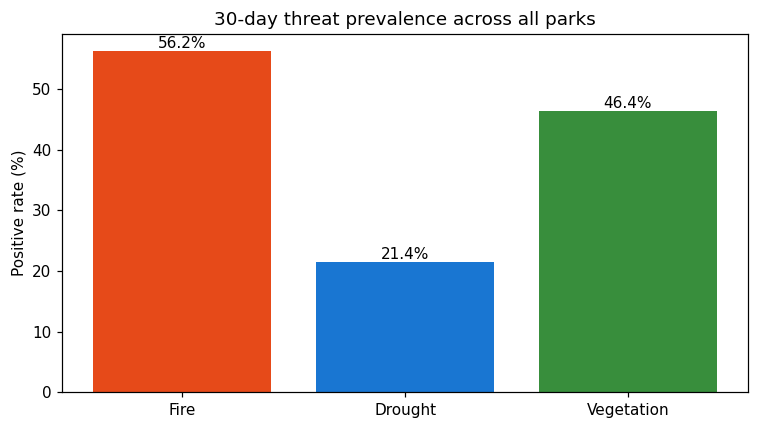

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
rates = [df[l].mean()*100 for l in LABELS]
names = ['Fire','Drought','Vegetation']
bars = ax.bar(names, rates, color=['#E64A19','#1976D2','#388E3C'])
for b, r in zip(bars, rates):
    ax.text(b.get_x()+b.get_width()/2, r+0.5, f'{r:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Positive rate (%)')
ax.set_title('30-day threat prevalence across all parks')
plt.tight_layout(); plt.show()

### Feature distribution example — NDVI by park
Vegetation index varies sharply by ecosystem, from dry Sahel (Chad Basin) to rainforest (Cross River).

C:\Users\fadhl\AppData\Local\Temp\ipykernel_68\1932115304.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[p.replace('_','\n') for p in parks], showfliers=False)


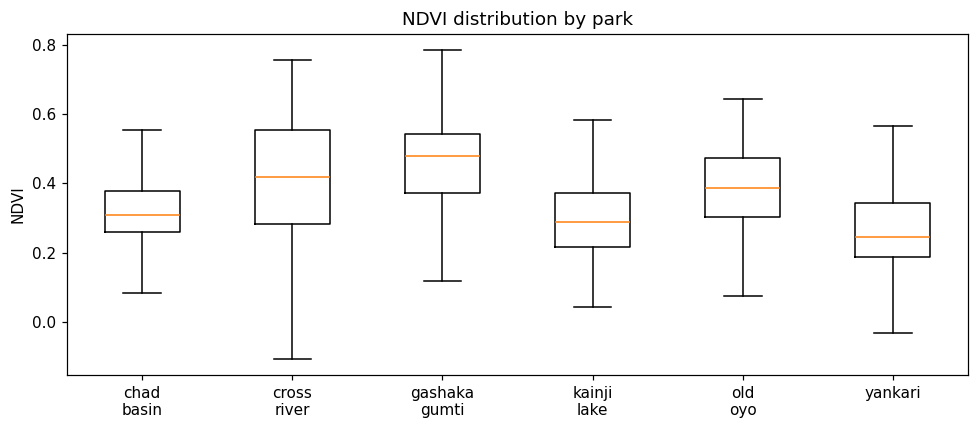

In [4]:
fig, ax = plt.subplots(figsize=(9,4))
parks = sorted(df['park'].unique())
data = [df[df['park']==p]['ndvi'].dropna() for p in parks]
ax.boxplot(data, labels=[p.replace('_','\n') for p in parks], showfliers=False)
ax.set_ylabel('NDVI')
ax.set_title('NDVI distribution by park')
plt.tight_layout(); plt.show()

### Temporal train / validation / test split
A strictly chronological split prevents leakage: the model trains on the past and is tested on genuinely future data.

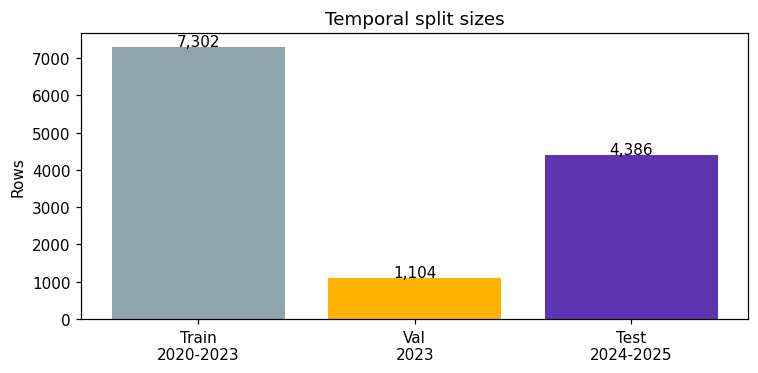

In [5]:
fig, ax = plt.subplots(figsize=(7,3.5))
order = ['train','val','test']
counts = [int((df['split']==s).sum()) for s in order]
ax.bar(['Train\n2020-2023','Val\n2023','Test\n2024-2025'], counts, color=['#90A4AE','#FFB300','#5E35B1'])
for i,c in enumerate(counts):
    ax.text(i, c+30, f'{c:,}', ha='center')
ax.set_ylabel('Rows')
ax.set_title('Temporal split sizes')
plt.tight_layout(); plt.show()

## 2. Model Architecture

Four architectures are benchmarked, each in a **supervised** and a **semi-supervised** variant — eight configurations in total. All produce three independent rolling 30-day probabilities (fire, drought, vegetation) per park-date, with class-weighted training and probability calibration.

| Family | Why included | Semi-supervised method |
|--------|--------------|------------------------|
| **Random Forest** | Strong tabular baseline, robust to small data | Self-training (confidence-gated pseudo-labels) |
| **XGBoost** | Gradient boosting often wins under <1,000 events | Self-training |
| **LSTM** | Captures temporal sequence in climate/NDVI | FixMatch consistency regularisation |
| **Transformer** | Long-horizon temporal attention | FixMatch consistency regularisation |

The semi-supervised variants exploit the abundant **unlabelled** park-dates (rows excluded from supervised training due to NDVI sensor gaps), following FixMatch (Sohn et al., 2020) for the neural models and confidence-gated self-training for the tree models.

In [6]:
meta = json.load(open(ROOT / 'results' / 'production' / 'metadata.json'))
print('PRODUCTION MODEL')
print(f"  Selected      : {meta['model_key']}  (v{meta['version']})")
print(f"  Trained       : {meta['training_date']}")
print(f"  Mean F2       : {meta['mean_f2']}")
print(f"  Reason        : {meta['selection_reason'][:110]}...")

PRODUCTION MODEL
  Selected      : rf_self  (v1.0.0)
  Trained       : 2026-06-01
  Mean F2       : 0.8575
  Reason        : Highest mean F2 (0.8575) across all three threats among all eight supervised and semi-supervised variants; mar...


## 3. Initial Performance Metrics

Evaluation uses **F2** (the primary metric — recall-weighted, because missing a threat is costlier than a false alarm), **ROC-AUC**, precision, and recall, computed on the held-out 2024–2025 test set with bootstrap confidence intervals. Every configuration is compared against a persistence baseline.

In [7]:
CONFIGS = ['rf_supervised','rf_self','xgb_supervised','xgb_self',
           'lstm_supervised','lstm_fixmatch','transformer_supervised','transformer_fixmatch']
LABELS = ['fire_within_30d','drought_within_30d','vegetation_within_30d']

rows = []
for cfg in CONFIGS:
    p = MODELS / cfg / 'test_metrics.json'
    if not p.exists():
        continue
    m = json.load(open(p))
    f2s = [m[l]['f2'] for l in LABELS]
    rows.append({'config': cfg, 'mean_F2': round(sum(f2s)/3, 4),
                 'fire_F2': round(m['fire_within_30d']['f2'],3),
                 'drought_F2': round(m['drought_within_30d']['f2'],3),
                 'veg_F2': round(m['vegetation_within_30d']['f2'],3)})
comp = pd.DataFrame(rows).sort_values('mean_F2', ascending=False).reset_index(drop=True)
comp

,config,mean_F2,fire_F2,drought_F2,veg_F2
0,rf_self,0.8575,0.942,0.885,0.746
1,rf_supervised,0.8565,0.944,0.882,0.744
2,xgb_supervised,0.8267,0.935,0.841,0.703
3,xgb_self,0.7979,0.938,0.829,0.628
4,lstm_supervised,0.7768,0.938,0.746,0.646
5,lstm_fixmatch,0.7361,0.924,0.712,0.572
6,transformer_fixmatch,0.7068,0.939,0.607,0.574
7,transformer_supervised,0.6886,0.941,0.596,0.529


### Mean F2 across all eight configurations

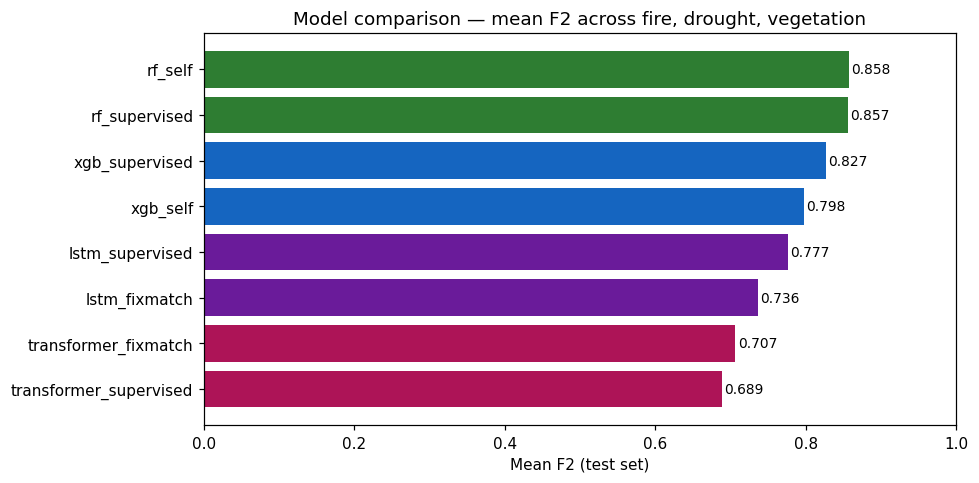

In [8]:
fig, ax = plt.subplots(figsize=(9,4.5))
c = comp.sort_values('mean_F2')
colors = ['#2E7D32' if 'rf' in x else '#1565C0' if 'xgb' in x else '#6A1B9A' if 'lstm' in x else '#AD1457' for x in c['config']]
ax.barh(c['config'], c['mean_F2'], color=colors)
for i,(cfg,v) in enumerate(zip(c['config'], c['mean_F2'])):
    ax.text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean F2 (test set)')
ax.set_title('Model comparison — mean F2 across fire, drought, vegetation')
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

### Production model — per-threat performance
The deployed model (**rf_self**, Random Forest with self-training) achieves the highest mean F2 and beats the persistence baseline on all three threats.

In [9]:
m = json.load(open(MODELS / meta['model_key'] / 'test_metrics.json'))
rows = []
for l, nice in zip(LABELS, ['Fire','Drought','Vegetation']):
    d = m[l]
    ci = d['bootstrap_f2']
    rows.append({'Threat': nice,
                 'F2': round(d['f2'],3),
                 'F2 95% CI': f"[{ci['ci_lower']:.3f}, {ci['ci_upper']:.3f}]",
                 'ROC-AUC': round(d['roc_auc'],3),
                 'Precision': round(d['precision'],3),
                 'Recall': round(d['recall'],3),
                 'Persistence F2': round(d['persistence_f2'],3),
                 'Beats baseline': d['beats_baseline']})
pd.DataFrame(rows).set_index('Threat')

,F2,F2 95% CI,ROC-AUC,Precision,Recall,Persistence F2,Beats baseline
Threat,,,,,,,
Fire,0.942,"[0.935, 0.949]",0.977,0.885,0.957,0.780,True
Drought,0.885,"[0.867, 0.901]",0.967,0.715,0.941,0.399,True
Vegetation,0.746,"[0.729, 0.762]",0.774,0.617,0.786,0.480,True


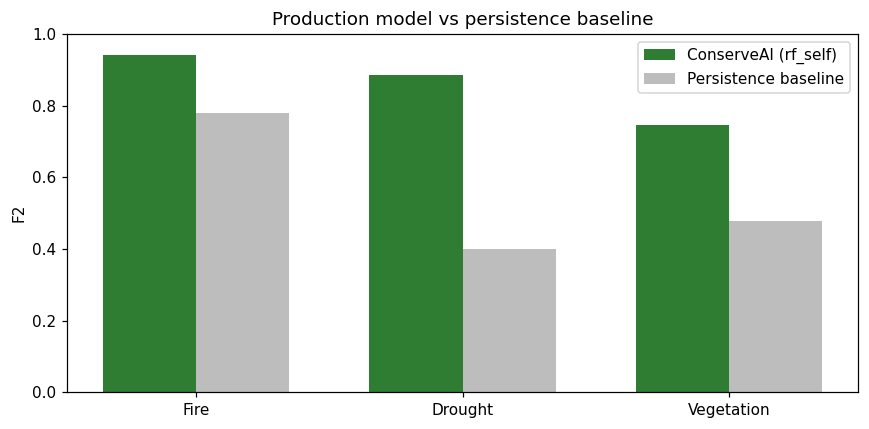

In [10]:
fig, ax = plt.subplots(figsize=(8,4))
threats = ['Fire','Drought','Vegetation']
model_f2 = [m[l]['f2'] for l in LABELS]
base_f2  = [m[l]['persistence_f2'] for l in LABELS]
x = np.arange(3); w = 0.35
ax.bar(x-w/2, model_f2, w, label='ConserveAI (rf_self)', color='#2E7D32')
ax.bar(x+w/2, base_f2,  w, label='Persistence baseline', color='#BDBDBD')
ax.set_xticks(x); ax.set_xticklabels(threats)
ax.set_ylabel('F2'); ax.set_ylim(0,1)
ax.set_title('Production model vs persistence baseline')
ax.legend()
plt.tight_layout(); plt.show()

## Summary

- **Data**: ~19k park-date records, 20 engineered features, 3 calibrated 30-day threat labels across 6 parks
- **Models**: 4 architectures × {supervised, semi-supervised} = 8 configurations, temporally validated
- **Selected**: Random Forest + self-training (`rf_self`), mean **F2 = 0.857**, beating persistence on every threat
- **Deployment**: served live through a FastAPI backend (see the Swagger UI demo) that runs daily inference and feeds an ILP-based intervention recommender

Supporting detail: `04_model_comparison` (per-park, calibration, confusion matrices), `05_semi_supervised_comparison` (8-config deep dive), `06_recommender_validation` (ILP).